# 10 — Iran-conflict event study

**Onderzoekshypothese**: sinds de Iran-oorlog op 28 februari 2026 gebruikt Donald
Trump zijn Truth Social account doelbewust om de olieprijs te beïnvloeden.

**Aanpak**: event-study op intraday WTI, S&P 500 en XLE (Energy Sector ETF) rond
Trump's Iran-gerelateerde posts. Vergelijking met (a) controle-posts in dezelfde
periode en (b) baseline volatiliteit zonder posts.

**Data sources:**
- `data/raw/posts_live.parquet` — Trump posts vanaf 2026-02-28 (via trumpstruth.org RSS)
- `data/raw/trump_truth_archive.csv` — historische posts t/m 2026-04-23 (Kaggle)
- yfinance — WTI (`CL=F`), S&P 500 (`SPY`), Energy sector ETF (`XLE`)

**Plan:**
1. Combineer live + archive posts naar één tijdreeks.
2. Filter Iran-gerelateerde posts met keyword-lijst.
3. Download intraday + daily marktdata sinds conflictstart.
4. Event-study: voor elke Iran-post, prijsbeweging in [t-1h, t+1h, t+4h, t+24h].
5. Aggregeer + vergelijk met controle-posts.
6. Anchor events: 5 zelf-gekozen ankermomenten markeren op timeline.
7. Robustheidscheck: drop Hormuz-cluster en re-test.
8. Classificeer Iran-posts met onze eigen sentiment + toxicity models (notebook 08/09).
9. Identifeer top-10 meest impactvolle posts voor scriptie-narratief.

**Gebruik**: *Restart Kernel and Run All Cells*. De cellen zijn nu sequentieel
geordend en hebben elkaars variabelen nodig — niet individueel uitvoeren tenzij
je weet dat alle voorgaande cellen al gedraaid hebben.


In [17]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

CONFLICT_START = pd.Timestamp("2026-02-28", tz="UTC")
TODAY = pd.Timestamp.now(tz="UTC").normalize()
print(f"Conflict period: {CONFLICT_START.date()} → {TODAY.date()}  ({(TODAY - CONFLICT_START).days} dagen)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Conflict period: 2026-02-28 → 2026-06-13  (105 dagen)


## 1. Load + combineer posts

Live posts (vanaf 28 feb 2026) + Kaggle archive (tot 23 apr 2026) → één DataFrame.


In [18]:
# Load posts vanaf conflictstart (scraper = single source of truth, geen Kaggle merge)
live_path = Path("../data/raw/posts_live.parquet")
if not live_path.exists():
    raise FileNotFoundError(
        "Run eerst de scraper:\n"
        "  python -m src.data.scrape_trumpstruth_rss --start 2026-02-28"
    )

combined = pd.read_parquet(live_path)
combined["timestamp_utc"] = pd.to_datetime(combined["timestamp_utc"], utc=True)
combined["post_id"] = combined["post_id"].astype(str)
combined = combined.drop_duplicates(subset="post_id", keep="first")
combined = combined[combined["timestamp_utc"] >= CONFLICT_START].sort_values("timestamp_utc").reset_index(drop=True)

print(f"Posts (scraper, vanaf {CONFLICT_START.date()}): {len(combined):,}")
print(f"Date range: {combined['timestamp_utc'].min()} → {combined['timestamp_utc'].max()}")

Posts (scraper, vanaf 2026-02-28): 2,161
Date range: 2026-02-28 01:26:06+00:00 → 2026-06-12 21:07:47+00:00


## 2. Filter Iran-gerelateerde posts

Keyword-lijst is breed gehouden — review de output handmatig en pas aan als nodig.


In [19]:
IRAN_KEYWORDS = [
    # Iran-specifiek
    "iran", "iranian", "tehran", "ayatollah", "khamenei", "raisi", "pezeshkian",
    "revolutionary guard", "irgc",
    # Geopolitiek
    "hormuz", "strait of hormuz", "persian gulf",
    "israel", "israeli", "netanyahu", "idf", "tel aviv",
    "houthi", "yemen", "hezbollah", "lebanon",
    # Energiebeleid
    "opec", "saudi", "saudi arabia", "riyadh", "mbs",
    "oil", "crude", "petroleum", "barrel", "gasoline",
    "drill", "drilling", "pipeline", "energy independence",
    # Militaire actie
    "strike", "airstrike", "missile", "nuclear",
    "sanctions", "embargo", "tariff",
]

# Case-insensitive substring match
pattern = "|".join(IRAN_KEYWORDS)
mask_iran = combined["text"].str.lower().str.contains(pattern, na=False, regex=True)

iran_posts = combined[mask_iran].copy()
control_posts = combined[~mask_iran].copy()

print(f"Iran-related posts:  {len(iran_posts):,}  ({len(iran_posts)/len(combined)*100:.1f}%)")
print(f"Control posts:       {len(control_posts):,}")
print(f"\nFirst 5 Iran posts:")
for _, row in iran_posts.head(5).iterrows():
    print(f"  [{row['timestamp_utc']}]  {row['text'][:130]}")

Iran-related posts:  309  (14.3%)
Control posts:       1,852

First 5 Iran posts:
  [2026-02-28 01:36:37+00:00]  Dr. Dawn Buckingham is the strong and highly popular Land Commissioner for Texas, a place I love and WON BIG three times, includin
  [2026-02-28 09:35:09+00:00]  Iran tried to interfere in 2020, 2024 elections to stop Trump, and now faces renewed war with United States: https:// justthenews.
  [2026-02-28 21:37:32+00:00]  Khamenei, one of the most evil people in History, is dead. This is not only Justice for the people of Iran, but for all Great Amer
  [2026-03-01 05:22:29+00:00]  Iran just stated that they are going to hit very hard today, harder than they have ever been hit before. THEY BETTER NOT DO THAT, 
  [2026-03-01 05:25:12+00:00]  Iran just stated that they are going to hit very hard today, harder than they have ever hit before. THEY BETTER NOT DO THAT, HOWEV


## 3. Download marktdata sinds conflictstart

Drie tickers, 2 granulariteiten:
- **Daily** (full window 28 feb → vandaag) voor de overall picture.
- **Hourly** (laatste 60 dagen via yfinance limiet) voor intraday event-study.


In [20]:
TICKERS = {
    "WTI": "CL=F",
    "SPY": "SPY",
    "XLE": "XLE",
}

def download_market(ticker_alias: str, ticker_symbol: str, start: pd.Timestamp, interval: str = "1d") -> pd.DataFrame:
    df = yf.download(ticker_symbol, start=start.date(), interval=interval, progress=False, auto_adjust=False)
    if df.empty:
        return df
    df.columns = [c.lower() for c in df.columns.get_level_values(0)] if df.columns.nlevels > 1 else [c.lower() for c in df.columns]
    df = df.reset_index().rename(columns={df.index.name or df.columns[0]: "datetime"})
    df.columns = [c.lower() for c in df.columns]
    if "datetime" not in df.columns:
        df = df.rename(columns={"date": "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("UTC")
    df["ticker"] = ticker_alias
    df["return"] = np.log(df["close"] / df["close"].shift(1))
    return df


# Daily
daily_frames = []
for alias, sym in TICKERS.items():
    print(f"Downloading {alias} daily…")
    daily_frames.append(download_market(alias, sym, CONFLICT_START, interval="1d"))
daily = pd.concat(daily_frames, ignore_index=True)

# Hourly (alleen voor laatste ~60 dagen)
hourly_start = max(CONFLICT_START, pd.Timestamp.now(tz="UTC") - timedelta(days=59))
hourly_frames = []
for alias, sym in TICKERS.items():
    print(f"Downloading {alias} hourly…")
    hourly_frames.append(download_market(alias, sym, hourly_start, interval="1h"))
hourly = pd.concat(hourly_frames, ignore_index=True)

print(f"\nDaily: {len(daily):,} rows ({daily['ticker'].value_counts().to_dict()})")
print(f"Hourly: {len(hourly):,} rows from {hourly_start.date()}")


Daily: 219 rows ({'WTI': 73, 'SPY': 73, 'XLE': 73})
Hourly: 1,534 rows from 2026-04-15


## 4. Anchor events

**Vul hieronder de 5 ankerevenementen in met echte data en korte beschrijving.**
De 5 voorgesteld door Claude zijn placeholders — pas aan naar wat jij weet over
het conflict. Het Strait of Hormuz event (11-12 april) is al ingevuld op basis
van eerdere bevindingen.


In [21]:
ANCHOR_EVENTS = [
    # (datum, label, korte beschrijving)
    ("2026-02-28", "Conflict start",       "Begin van de Iran-oorlog."),
    ("2026-03-XX", "Eerste escalatie",     "VUL IN: eerste grote escalatie-moment."),
    ("2026-04-11", "Hormuz blockade",      "Trump kondigt naval blockade van Strait of Hormuz aan."),
    ("2026-04-XX", "OPEC respons",         "VUL IN: OPEC emergency meeting of belangrijke productie-aankondiging."),
    ("2026-06-02", "Recent moment",        "VUL IN: meest recente ankermoment voor je verdediging."),
]

anchor_df = pd.DataFrame(ANCHOR_EVENTS, columns=["date", "label", "description"])
anchor_df["date"] = pd.to_datetime(anchor_df["date"], utc=True, errors="coerce")
print(anchor_df.to_string(index=False))

                     date            label                                                           description
2026-02-28 00:00:00+00:00   Conflict start                                             Begin van de Iran-oorlog.
                      NaT Eerste escalatie                                VUL IN: eerste grote escalatie-moment.
2026-04-11 00:00:00+00:00  Hormuz blockade                Trump kondigt naval blockade van Strait of Hormuz aan.
                      NaT     OPEC respons VUL IN: OPEC emergency meeting of belangrijke productie-aankondiging.
2026-06-02 00:00:00+00:00    Recent moment                VUL IN: meest recente ankermoment voor je verdediging.


## 5. Timeline: marktprijzen + post density + ankers


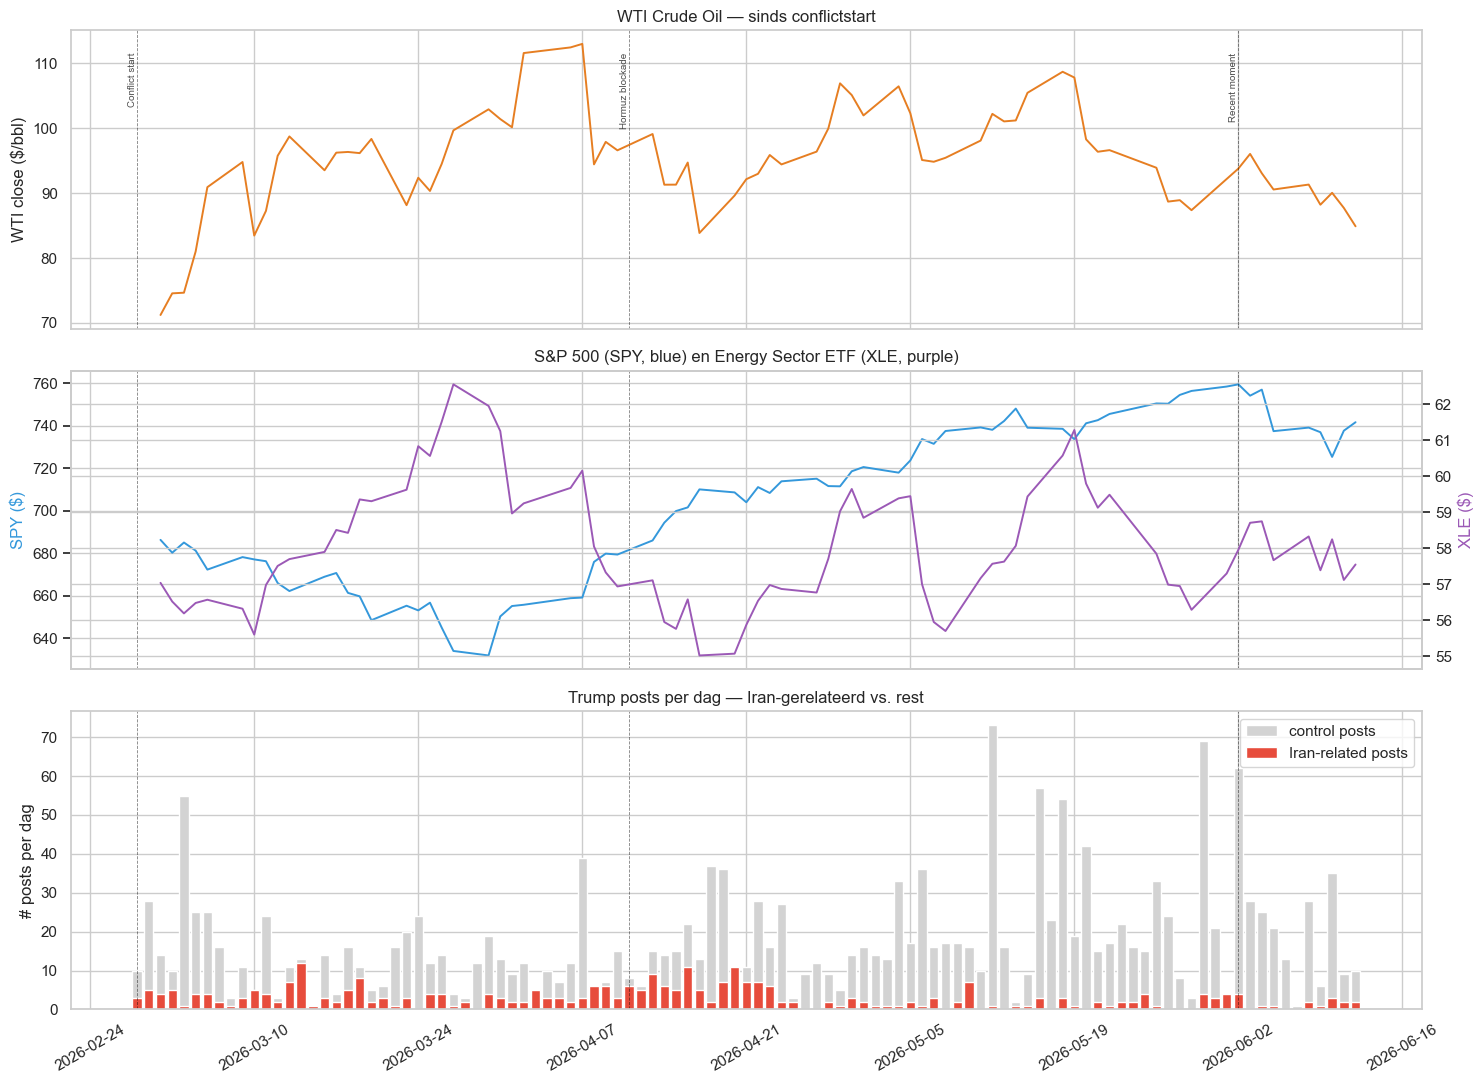

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Top: WTI olie prijs (daily close)
wti = daily[daily["ticker"] == "WTI"].sort_values("datetime")
axes[0].plot(wti["datetime"], wti["close"], color="#e67e22", linewidth=1.4)
axes[0].set_ylabel("WTI close ($/bbl)")
axes[0].set_title("WTI Crude Oil — sinds conflictstart")

# Middle: SPY (S&P 500) + XLE (energy)
spy = daily[daily["ticker"] == "SPY"].sort_values("datetime")
xle = daily[daily["ticker"] == "XLE"].sort_values("datetime")
ax_spy = axes[1]
ax_xle = ax_spy.twinx()
ax_spy.plot(spy["datetime"], spy["close"], color="#3498db", linewidth=1.4, label="SPY")
ax_xle.plot(xle["datetime"], xle["close"], color="#9b59b6", linewidth=1.4, label="XLE")
ax_spy.set_ylabel("SPY ($)", color="#3498db")
ax_xle.set_ylabel("XLE ($)", color="#9b59b6")
ax_spy.set_title("S&P 500 (SPY, blue) en Energy Sector ETF (XLE, purple)")

# Bottom: Post density per dag (Iran vs control)
iran_daily = iran_posts.set_index("timestamp_utc").resample("D").size()
control_daily = control_posts.set_index("timestamp_utc").resample("D").size()
axes[2].bar(control_daily.index, control_daily.values, color="lightgray", width=0.8, label="control posts")
axes[2].bar(iran_daily.index, iran_daily.values, color="#e74c3c", width=0.8, label="Iran-related posts")
axes[2].set_ylabel("# posts per dag")
axes[2].set_title("Trump posts per dag — Iran-gerelateerd vs. rest")
axes[2].legend(loc="upper right")

# Anchor lines op alle subplots
for d, label, _ in ANCHOR_EVENTS:
    d = pd.to_datetime(d, utc=True, errors="coerce")
    if pd.isna(d):
        continue
    for ax in axes:
        ax.axvline(d, color="black", linewidth=0.6, alpha=0.5, linestyle="--")
    axes[0].annotate(label, xy=(d, axes[0].get_ylim()[1]*0.97),
                     xytext=(d, axes[0].get_ylim()[1]*0.97), rotation=90,
                     fontsize=7, ha="right", va="top", color="black", alpha=0.7)

axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(axes[-1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

## 6. Per-post event study (intraday)

Voor elke Iran-post, kijk naar WTI/SPY/XLE prijs t.o.v. **t-1h, t+1h, t+4h, t+24h**.
Hourly data dekt alleen de laatste ~60 dagen, dus alleen recente posts.


In [23]:
def compute_event_returns(post_time: pd.Timestamp, market_df: pd.DataFrame,
                            windows: list = [-1, 1, 4, 24]) -> dict:
    """Voor één post, return log-returns voor de gegeven windows (uren)."""
    out = {}
    pre = market_df[market_df["datetime"] <= post_time]
    if pre.empty:
        return {f"ret_{w}h": np.nan for w in windows}
    p0 = pre.iloc[-1]["close"]
    for w in windows:
        target_time = post_time + pd.Timedelta(hours=w)
        if w < 0:
            pre_w = market_df[market_df["datetime"] <= target_time]
            if pre_w.empty:
                out[f"ret_{w}h"] = np.nan
                continue
            p1 = pre_w.iloc[-1]["close"]
            out[f"ret_{w}h"] = float(np.log(p0 / p1))
        else:
            post = market_df[market_df["datetime"] >= target_time]
            if post.empty:
                out[f"ret_{w}h"] = np.nan
                continue
            p1 = post.iloc[0]["close"]
            out[f"ret_{w}h"] = float(np.log(p1 / p0))
    return out


# Alleen voor posts in het hourly data window
recent_iran = iran_posts[iran_posts["timestamp_utc"] >= hourly_start].copy()
print(f"Iran posts in hourly window: {len(recent_iran)}")

results_rows = []
for _, row in recent_iran.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"],
            "text": row["text"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    results_rows.append(rec)

event_df = pd.DataFrame(results_rows)
print(f"\nEvent study: {len(event_df)} Iran posts with intraday returns")
print(event_df.filter(like="WTI_ret").describe().round(5))

Iran posts in hourly window: 135

Event study: 135 Iran posts with intraday returns
       WTI_ret_-1h  WTI_ret_1h  WTI_ret_4h  WTI_ret_24h
count    135.00000   135.00000   134.00000    133.00000
mean      -0.00021     0.00564     0.00726      0.01042
std        0.00995     0.02413     0.02612      0.04033
min       -0.03872    -0.04857    -0.04857     -0.10425
25%       -0.00215    -0.00539    -0.00537     -0.02290
50%        0.00000     0.00133     0.00324      0.01703
75%        0.00268     0.01698     0.02521      0.03772
max        0.03016     0.05912     0.05912      0.09111


## 7. Aggregaat-effect: Iran posts vs. control posts


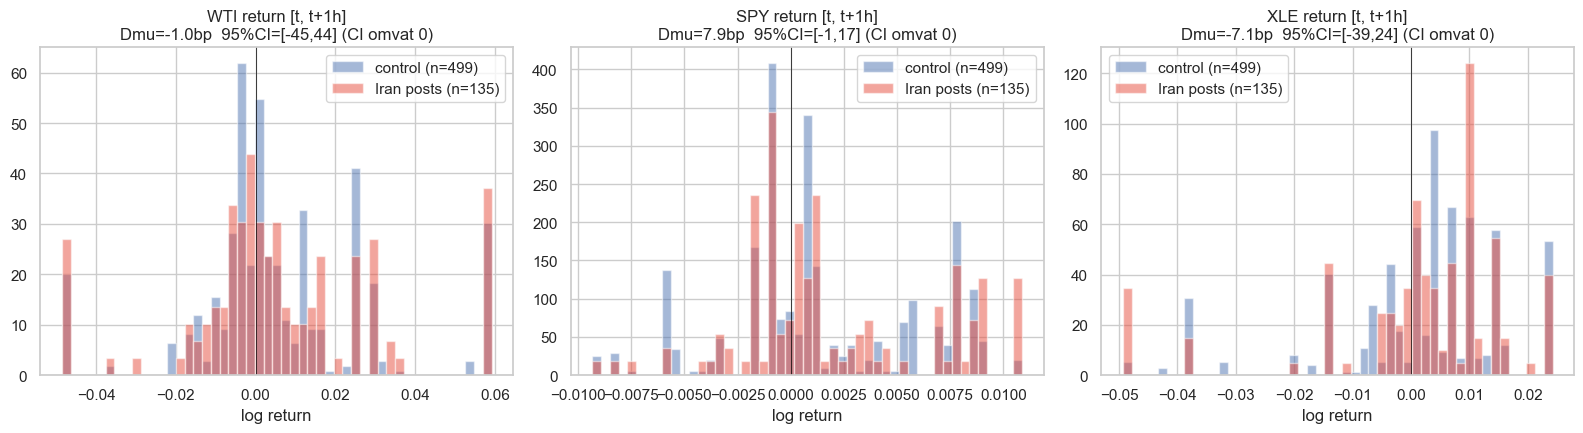

In [24]:
# Controle-groep: random sample van non-Iran posts in zelfde window
from src.evaluation.bootstrap import bootstrap_diff_bp

n_control = min(500, len(control_posts[control_posts["timestamp_utc"] >= hourly_start]))
control_sample = control_posts[control_posts["timestamp_utc"] >= hourly_start].sample(
    n=n_control, random_state=42
)

control_rows = []
for _, row in control_sample.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    control_rows.append(rec)
control_df = pd.DataFrame(control_rows)

# Vergelijk verdelingen (bootstrap-CI i.p.v. Welch t-toets)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, alias in zip(axes, TICKERS):
    col = f"{alias}_ret_1h"
    iran_vals = event_df[col].dropna()
    ctrl_vals = control_df[col].dropna()

    bins = np.linspace(
        np.percentile(np.concatenate([iran_vals, ctrl_vals]), 1),
        np.percentile(np.concatenate([iran_vals, ctrl_vals]), 99),
        50,
    )
    ax.hist(ctrl_vals, bins=bins, alpha=0.5, density=True, label=f"control (n={len(ctrl_vals)})")
    ax.hist(iran_vals, bins=bins, alpha=0.5, density=True, label=f"Iran posts (n={len(iran_vals)})", color="#e74c3c")
    ax.axvline(0, color="black", linewidth=0.5)
    b = bootstrap_diff_bp(iran_vals, ctrl_vals, stat=np.mean)
    flag = "CI sluit 0 uit" if b["excludes_zero"] else "CI omvat 0"
    ax.set_title(f"{alias} return [t, t+1h]\nDmu={b['obs_diff_bp']:.1f}bp  95%CI=[{b['ci_low_bp']:.0f},{b['ci_high_bp']:.0f}] ({flag})")
    ax.set_xlabel("log return")
    ax.legend()
plt.tight_layout()
plt.show()


In [25]:
# Bootstrap 95%-CI per ticker x window (vervangt Welch t-toets)
from src.evaluation.bootstrap import bootstrap_diff_bp

test_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        iran_vals = event_df[col].dropna()
        ctrl_vals = control_df[col].dropna()
        if len(iran_vals) < 10 or len(ctrl_vals) < 10:
            continue
        b = bootstrap_diff_bp(iran_vals, ctrl_vals, stat=np.mean)
        test_rows.append({
            "ticker": alias, "window": f"{w}h",
            "n_iran": len(iran_vals), "n_ctrl": len(ctrl_vals),
            "mean_iran_bp": iran_vals.mean()*1e4,
            "mean_ctrl_bp": ctrl_vals.mean()*1e4,
            "diff_bp": b["obs_diff_bp"],
            "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
            "excludes_zero": b["excludes_zero"],
        })
tests = pd.DataFrame(test_rows).round(1)
print("\n=== Bootstrap 95%-CI: Iran posts vs control (mean-verschil, bp) ===")
print("(excludes_zero=True is bootstrap-equivalent van significant; geen Bonferroni nodig)")
print(tests.to_string(index=False))



=== Bootstrap 95%-CI: Iran posts vs control (mean-verschil, bp) ===
(excludes_zero=True is bootstrap-equivalent van significant; geen Bonferroni nodig)
ticker window  n_iran  n_ctrl  mean_iran_bp  mean_ctrl_bp  diff_bp  ci_low_bp  ci_high_bp  excludes_zero
   WTI    -1h     135     500          -2.1           4.4     -6.5      -24.4        11.3          False
   WTI     1h     135     499          56.4          57.4     -1.0      -45.0        43.6          False
   WTI     4h     134     498          72.6          67.0      5.6      -41.1        55.2          False
   WTI    24h     133     492         104.2          30.8     73.3       -2.8       148.6          False
   SPY    -1h     135     499           5.3          -0.7      6.0        2.2        10.0           True
   SPY     1h     135     499          20.7          12.7      7.9       -0.7        16.8          False
   SPY     4h     134     497          24.0           9.9     14.0        4.4        23.5           True
   SPY 

## 7b. Robustheidscheck: drop Hormuz-cluster (11-12 april)

Een groot deel van het top-10 impact komt van één 24-uurs venster rond de
Strait of Hormuz blockade aankondiging. Cruciale check: blijft het effect
overeind als we deze cluster verwijderen?

- Δμ blijft groot en p<0.05 → effect is breed fenomeen, niet één event
- Δμ daalt fors maar p<0.05 → kleiner maar reëel patroon over hele periode
- Δμ dicht bij 0, p>0.05 → het hele effect kwam van die ene cluster


In [26]:
# Robuustheid: drop top-impact cluster (11-12 april) en her-schat met bootstrap
from src.evaluation.bootstrap import bootstrap_diff_bp

mask_cluster = event_df["timestamp_utc"].dt.date.isin([
    pd.Timestamp("2026-04-11").date(),
    pd.Timestamp("2026-04-12").date(),
])
event_no_cluster = event_df[~mask_cluster]
print(f"Iran posts after dropping Hormuz cluster: {len(event_no_cluster)} (was {len(event_df)})")
print()

robust_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        iran_no = event_no_cluster[col].dropna()
        ctrl = control_df[col].dropna()
        if len(iran_no) < 10 or len(ctrl) < 10:
            continue
        b = bootstrap_diff_bp(iran_no, ctrl, stat=np.mean)
        robust_rows.append({
            "ticker": alias, "window": f"{w}h",
            "n_iran_no_cluster": len(iran_no), "n_ctrl": len(ctrl),
            "mean_iran_bp": iran_no.mean()*1e4,
            "mean_ctrl_bp": ctrl.mean()*1e4,
            "diff_bp": b["obs_diff_bp"],
            "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
            "excludes_zero": b["excludes_zero"],
        })
robust_tests = pd.DataFrame(robust_rows).round(1)
print("=== Bootstrap 95%-CI: Iran posts vs control (Hormuz cluster excluded) ===")
print(robust_tests.to_string(index=False))


Iran posts after dropping Hormuz cluster: 135 (was 135)

=== Bootstrap 95%-CI: Iran posts vs control (Hormuz cluster excluded) ===
ticker window  n_iran_no_cluster  n_ctrl  mean_iran_bp  mean_ctrl_bp  diff_bp  ci_low_bp  ci_high_bp  excludes_zero
   WTI    -1h                135     500          -2.1           4.4     -6.5      -24.4        11.3          False
   WTI     1h                135     499          56.4          57.4     -1.0      -45.0        43.6          False
   WTI     4h                134     498          72.6          67.0      5.6      -41.1        55.2          False
   WTI    24h                133     492         104.2          30.8     73.3       -2.8       148.6          False
   SPY    -1h                135     499           5.3          -0.7      6.0        2.2        10.0           True
   SPY     1h                135     499          20.7          12.7      7.9       -0.7        16.8          False
   SPY     4h                134     497          24.0   

## 8. Top-10 meest impactvolle Iran posts

Sorteer op absolute WTI return [t, t+1h]. Dit zijn de posts waarvan het verhaal
in je scriptie waarschijnlijk komt.


In [27]:
# Top-10 meest impactvolle Iran posts (gededupliceerd per uur-window)
event_df["WTI_abs_ret_1h"] = event_df["WTI_ret_1h"].abs()
event_df["hour_bin"] = event_df["timestamp_utc"].dt.floor("1h")

# Per uur de eerste post houden — voorkomt dat 5 posts uit hetzelfde event
# allemaal als "top-10 events" verschijnen
event_unique = (
    event_df.sort_values("timestamp_utc")
    .drop_duplicates(subset="hour_bin", keep="first")
)

top_impact = event_unique.nlargest(10, "WTI_abs_ret_1h")

print(f"Top-10 distinct events (n posts in cluster vermeld tussen haakjes):\n")
for _, row in top_impact.iterrows():
    # Tel hoeveel posts er nog meer waren in dezelfde uur-window
    n_in_cluster = (event_df["hour_bin"] == row["hour_bin"]).sum()
    direction = "↑" if row["WTI_ret_1h"] > 0 else "↓"
    print(f"[{row['timestamp_utc']}]  WTI {direction}{abs(row['WTI_ret_1h'])*100:.2f}%  "
          f"SPY {row['SPY_ret_1h']*100:+.2f}%  XLE {row['XLE_ret_1h']*100:+.2f}%  "
          f"[{n_in_cluster} post{'s' if n_in_cluster > 1 else ''} in dit uur]")
    print(f"  {row['text'][:300]}")
    print()

Top-10 distinct events (n posts in cluster vermeld tussen haakjes):

[2026-04-18 02:25:40+00:00]  WTI ↑5.91%  SPY -0.16%  XLE +0.93%  [2 posts in dit uur]
  President Xi is very happy that the Strait of Hormuz is open and/or rapidly opening. Our meeting in China will be a special one and, potentially, Historic. I look forward to being with President Xi — Much will be accomplished! President DONALD J. TRUMP

[2026-04-19 01:07:11+00:00]  WTI ↑5.91%  SPY -0.16%  XLE +0.93%  [1 post in dit uur]
  Whether people like Israel or not, they have proven to be a GREAT Ally of the United States of America. They are Courageous, Bold, Loyal, and Smart and, unlike others that have shown their true colors in a moment of conflict and stress, Israel fights hard, and knows how to WIN! President DJT

[2026-04-19 12:10:10+00:00]  WTI ↑5.91%  SPY -0.16%  XLE +0.93%  [1 post in dit uur]
  Iran decided to fire bullets yesterday in the Strait of Hormuz — A Total Violation of our Ceasefire Agreement! Many of th

## 9. Sentiment + toxicity van Iran-posts

Gebruik onze eigen classifiers (notebook 08/09) om de Iran-posts te
karakteriseren. Verschilt hun sentiment/toxicity van non-Iran posts?


In [28]:
# Load eigen classifiers
try:
    sentiment_vec = joblib.load("../models/sentiment/vectorizer.joblib")
    sentiment_clf = joblib.load("../models/sentiment/logistic_l1.joblib")
    toxicity_vec = joblib.load("../models/toxicity/vectorizer.joblib")
    toxicity_clf = joblib.load("../models/toxicity/logistic_l1.joblib")
    CLASSIFIERS_AVAILABLE = True
except FileNotFoundError as e:
    print(f"Classifiers niet gevonden — run eerst notebook 08 en 09. {e}")
    CLASSIFIERS_AVAILABLE = False

if CLASSIFIERS_AVAILABLE:
    from src.data.preprocess import clean_text

    def score_posts(df_posts):
        cleaned = df_posts["text"].apply(clean_text)
        X_sent = sentiment_vec.transform(cleaned)
        X_tox = toxicity_vec.transform(cleaned)
        df = df_posts.copy()
        df["pred_sentiment"] = sentiment_clf.predict(X_sent)
        df["proba_high_tox"] = toxicity_clf.predict_proba(X_tox)[:, 1]
        return df

    iran_scored = score_posts(iran_posts)
    control_scored = score_posts(control_posts.sample(min(2000, len(control_posts)), random_state=42))

    print("Sentiment distributie (Iran vs Control):")
    sent_compare = pd.DataFrame({
        "iran": iran_scored["pred_sentiment"].value_counts(normalize=True).round(3),
        "control": control_scored["pred_sentiment"].value_counts(normalize=True).round(3),
    })
    print(sent_compare)
    print(f"\nMean toxicity probability:")
    print(f"  Iran posts:    {iran_scored['proba_high_tox'].mean():.3f}")
    print(f"  Control posts: {control_scored['proba_high_tox'].mean():.3f}")

    from src.evaluation.bootstrap import bootstrap_diff_ci
    b = bootstrap_diff_ci(iran_scored["proba_high_tox"], control_scored["proba_high_tox"], stat=np.mean)
    print(f"  Bootstrap dmu: {b['obs_diff']:+.3f}  95%CI=[{b['ci_low']:+.3f}, {b['ci_high']:+.3f}]  (0 uitgesloten={b['excludes_zero']})")

Sentiment distributie (Iran vs Control):
                 iran  control
pred_sentiment                
negative        0.333    0.096
neutral         0.159    0.587
positive        0.508    0.316

Mean toxicity probability:
  Iran posts:    0.396
  Control posts: 0.334
  Bootstrap dmu: +0.062  95%CI=[+0.028, +0.096]  (0 uitgesloten=True)


In [29]:
# Granger causality test (v2 — robuuste alignment)
from statsmodels.tsa.stattools import grangercausalitytests

# Begin met WTI hourly returns als base
wti_h = (
    hourly[hourly["ticker"] == "WTI"]
    .set_index("datetime")
    .sort_index()[["return"]]
    .rename(columns={"return": "wti_ret"})
)
print(f"WTI hourly observations: {len(wti_h)}")

# Voor elk WTI-uur: tel Iran-posts in dat uur (van begin-uur tot eind-uur)
def count_posts_in_hour(hour_ts):
    return ((iran_posts["timestamp_utc"] >= hour_ts) &
            (iran_posts["timestamp_utc"] < hour_ts + pd.Timedelta(hours=1))).sum()

wti_h["iran_posts"] = wti_h.index.to_series().apply(count_posts_in_hour)

# Drop NaNs in returns (eerste rij heeft geen return)
df_granger = wti_h.dropna()
print(f"Granger sample: {len(df_granger)} hourly observations")
print(f"Hours with ≥1 Iran post: {(df_granger['iran_posts'] > 0).sum()}")
print(f"Total Iran posts in window: {df_granger['iran_posts'].sum()}\n")

if len(df_granger) < 20:
    print("ERROR: te weinig observaties. Check of hourly data correct geladen is.")
else:
    # Test 1: doen Iran-posts WTI returns Granger-causeren?
    print("=== Test 1: Iran posts → WTI returns ===")
    print("(als p<0.05: past Iran posts helpen toekomstige WTI returns voorspellen)")
    result_1 = grangercausalitytests(df_granger[["wti_ret", "iran_posts"]], maxlag=4, verbose=False)
    for lag, r in result_1.items():
        print(f"  lag={lag}h:  F={r[0]['ssr_ftest'][0]:.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

    print("\n=== Test 2: WTI returns → Iran posts (reverse) ===")
    print("(als p<0.05: past WTI returns helpen toekomstige Iran-posts voorspellen)")
    result_2 = grangercausalitytests(df_granger[["iran_posts", "wti_ret"]], maxlag=4, verbose=False)
    for lag, r in result_2.items():
        print(f"  lag={lag}h:  F={r[0]['ssr_ftest'][0]:.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

WTI hourly observations: 946
Granger sample: 945 hourly observations
Hours with ≥1 Iran post: 71
Total Iran posts in window: 90

=== Test 1: Iran posts → WTI returns ===
(als p<0.05: past Iran posts helpen toekomstige WTI returns voorspellen)
  lag=1h:  F=0.104  p=0.7470
  lag=2h:  F=0.075  p=0.9278
  lag=3h:  F=0.120  p=0.9486
  lag=4h:  F=0.524  p=0.7185

=== Test 2: WTI returns → Iran posts (reverse) ===
(als p<0.05: past WTI returns helpen toekomstige Iran-posts voorspellen)
  lag=1h:  F=0.193  p=0.6609
  lag=2h:  F=4.808  p=0.0084
  lag=3h:  F=3.710  p=0.0114
  lag=4h:  F=2.980  p=0.0185


In [30]:
# Granger causality op 5-minuten resolutie (yfinance limiet)
from statsmodels.tsa.stattools import grangercausalitytests

# Download WTI 5-min data (max ~60 dagen via yfinance)
print("Downloading WTI 5-min data (60 days)…")
wti_5m_raw = yf.download("CL=F", period="60d", interval="5m", progress=False, auto_adjust=False)
if wti_5m_raw.columns.nlevels > 1:
    wti_5m_raw.columns = [c.lower() for c in wti_5m_raw.columns.get_level_values(0)]
else:
    wti_5m_raw.columns = [c.lower() for c in wti_5m_raw.columns]
wti_5m = wti_5m_raw.reset_index()
wti_5m.columns = [c.lower() for c in wti_5m.columns]
wti_5m["datetime"] = pd.to_datetime(wti_5m["datetime"], utc=True)
wti_5m = wti_5m.set_index("datetime").sort_index()
wti_5m["ret"] = np.log(wti_5m["close"] / wti_5m["close"].shift(1))

print(f"WTI 5m bars: {len(wti_5m):,}")
print(f"Period: {wti_5m.index.min()} → {wti_5m.index.max()}")

# Count Iran posts per 5m bar
start = wti_5m.index.min()
end = wti_5m.index.max()
iran_in_window = iran_posts[(iran_posts["timestamp_utc"] >= start) & (iran_posts["timestamp_utc"] <= end)].copy()
iran_in_window["bin_5m"] = iran_in_window["timestamp_utc"].dt.floor("5min")
post_counts = iran_in_window.groupby("bin_5m").size()
wti_5m["iran_posts"] = post_counts.reindex(wti_5m.index, fill_value=0)

df_5m = wti_5m[["ret", "iran_posts"]].dropna()
print(f"\n5-min sample: {len(df_5m):,} observations")
print(f"Bars met ≥1 Iran post: {(df_5m['iran_posts'] > 0).sum()}")
print(f"Total Iran posts in sample: {df_5m['iran_posts'].sum()}\n")

if len(df_5m) < 100:
    print("ERROR: te weinig observaties.")
else:
    lags = [1, 2, 3, 6, 12]   # = 5, 10, 15, 30, 60 minuten
    print("=== Test 1: Iran posts → WTI returns ===")
    print("(als p<0.05: post in T-X helpt return in T voorspellen)")
    result_1 = grangercausalitytests(df_5m[["ret", "iran_posts"]], maxlag=lags, verbose=False)
    for lag, r in result_1.items():
        mins = lag * 5
        print(f"  lag={lag} ({mins:>3d}min):  F={r[0]['ssr_ftest'][0]:6.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

    print("\n=== Test 2: WTI returns → Iran posts (reverse) ===")
    result_2 = grangercausalitytests(df_5m[["iran_posts", "ret"]], maxlag=lags, verbose=False)
    for lag, r in result_2.items():
        mins = lag * 5
        print(f"  lag={lag} ({mins:>3d}min):  F={r[0]['ssr_ftest'][0]:6.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

WTI 5m bars: 13,499
Period: 2026-04-02 04:00:00+00:00 → 2026-06-12 20:55:00+00:00

5-min sample: 13,498 observations
Bars met ≥1 Iran post: 118
Total Iran posts in sample: 127

=== Test 1: Iran posts → WTI returns ===
(als p<0.05: post in T-X helpt return in T voorspellen)
  lag=1 (  5min):  F= 1.392  p=0.2381
  lag=2 ( 10min):  F= 0.692  p=0.5004
  lag=3 ( 15min):  F= 0.462  p=0.7088
  lag=6 ( 30min):  F= 0.274  p=0.9493
  lag=12 ( 60min):  F= 0.620  p=0.8271

=== Test 2: WTI returns → Iran posts (reverse) ===
  lag=1 (  5min):  F= 0.576  p=0.4479
  lag=2 ( 10min):  F= 0.328  p=0.7201
  lag=3 ( 15min):  F= 0.222  p=0.8811
  lag=6 ( 30min):  F= 0.413  p=0.8712
  lag=12 ( 60min):  F= 0.965  p=0.4798


XLE (WTI-proxy) volume z-score in post-uur (Twelve Data 1-min)
  Iran posts (n=66): mean z = +0.293
  Controle   (n=139): mean z = +0.047
  verschil=+0.246 sigma  95%CI=[+0.041, +0.456]  (0 uitgesloten=True)


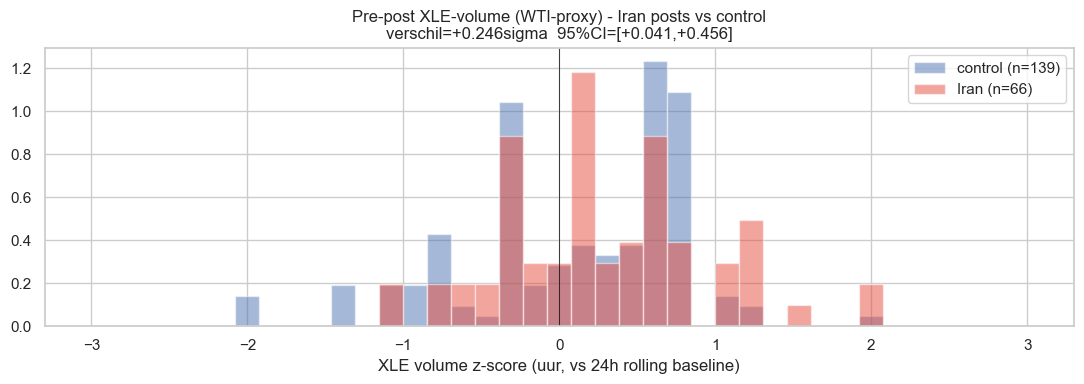

In [31]:
from src.evaluation.bootstrap import bootstrap_diff_ci

# Volume z-score uit lokale Twelve Data 1-min parquet: XLE als WTI-proxy.
# (Op de gratis Twelve Data tier zijn WTI-futures niet beschikbaar; XLE = energiesector-ETF,
#  de gedocumenteerde WTI-proxy op intraday-niveau. Robuuster dan yfinance-uurdata.)
xle_1m = pd.read_parquet("../data/processed/intraday_xle_iran_1min.parquet")
xle_1m["datetime"] = pd.to_datetime(xle_1m["datetime"], utc=True)

vol_h = xle_1m.set_index("datetime")["volume"].resample("1h").sum()
vol_h = vol_h[vol_h > 0]
log_vol = np.log(vol_h.clip(lower=1))
vol_z = ((log_vol - log_vol.rolling(24, min_periods=12).mean())
         / log_vol.rolling(24, min_periods=12).std()).dropna().to_dict()

def get_vol_zscore_at(post_ts):
    return vol_z.get(post_ts.floor("1h"), np.nan)

iran_z    = iran_posts["timestamp_utc"].apply(get_vol_zscore_at).dropna()
control_z = control_posts["timestamp_utc"].apply(get_vol_zscore_at).dropna()

b = bootstrap_diff_ci(iran_z, control_z, stat=np.mean)
print("XLE (WTI-proxy) volume z-score in post-uur (Twelve Data 1-min)")
print(f"  Iran posts (n={len(iran_z)}): mean z = {iran_z.mean():+.3f}")
print(f"  Controle   (n={len(control_z)}): mean z = {control_z.mean():+.3f}")
print(f"  verschil={b['obs_diff']:+.3f} sigma  95%CI=[{b['ci_low']:+.3f}, {b['ci_high']:+.3f}]  (0 uitgesloten={b['excludes_zero']})")

fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(-3, 3, 40)
ax.hist(control_z, bins=bins, alpha=0.5, density=True, label=f"control (n={len(control_z)})")
ax.hist(iran_z, bins=bins, alpha=0.5, density=True, label=f"Iran (n={len(iran_z)})", color="#e74c3c")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("XLE volume z-score (uur, vs 24h rolling baseline)")
ax.set_title(f"Pre-post XLE-volume (WTI-proxy) - Iran posts vs control\n"
             f"verschil={b['obs_diff']:+.3f}sigma  95%CI=[{b['ci_low']:+.3f},{b['ci_high']:+.3f}]")
ax.legend()
plt.tight_layout()
plt.show()


=== Price position in 4u window voor post ===
(0 = post valt bij lokaal dieptepunt; 1 = post valt bij lokaal hoogtepunt; 0.5 = middenin)
Iran posts (n=  2): mean = 0.500  median = 0.500
Control    (n= 80): mean = 0.663  median = 0.783

Bootstrap Dmu = -0.163  95%CI=[-0.717, +0.392]  (0 uitgesloten=False)

Interpretatie:
  CI volledig < 0  -> posts vallen bij dieptepunten (consistent met buy-low-then-pump)
  CI omvat 0       -> posts vallen willekeurig binnen 4u range


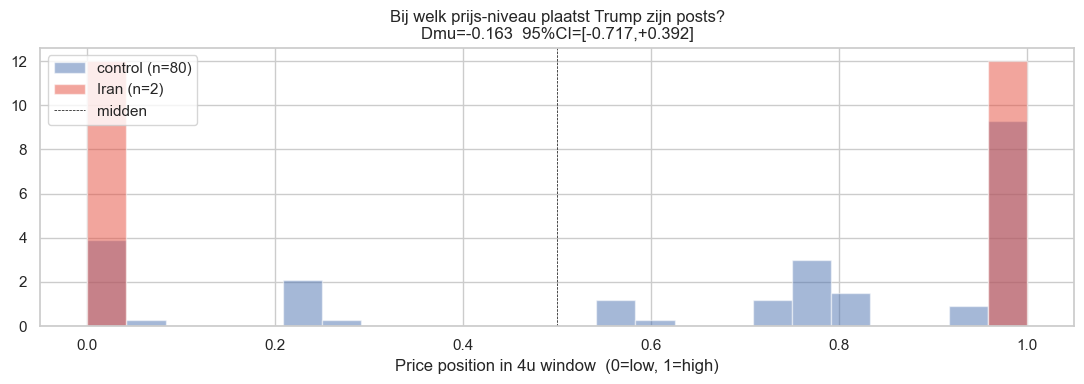

In [32]:
# Price-timing: waar staat WTI bij de post t.o.v. 4u-range?
from src.evaluation.bootstrap import bootstrap_diff_bp

def price_position_in_window(post_ts, window_h=4):
    pt = post_ts.floor("1h")
    window_start = pt - pd.Timedelta(hours=window_h)
    sub = wti_hour.loc[(wti_hour.index >= window_start) & (wti_hour.index <= pt)]
    if len(sub) < 3:
        return np.nan
    p_min, p_max = sub["close"].min(), sub["close"].max()
    p_at_post = sub.iloc[-1]["close"]
    return 0.5 if p_max == p_min else (p_at_post - p_min) / (p_max - p_min)


iran_pos = iran_in_h["timestamp_utc"].apply(price_position_in_window).dropna()
control_pos = control_in_h["timestamp_utc"].apply(price_position_in_window).dropna()

print("=== Price position in 4u window voor post ===")
print("(0 = post valt bij lokaal dieptepunt; 1 = post valt bij lokaal hoogtepunt; 0.5 = middenin)")
print(f"Iran posts (n={len(iran_pos):>3}): mean = {iran_pos.mean():.3f}  median = {iran_pos.median():.3f}")
print(f"Control    (n={len(control_pos):>3}): mean = {control_pos.mean():.3f}  median = {control_pos.median():.3f}")
b = bootstrap_diff_bp(iran_pos, control_pos, stat=np.mean)
print(f"\nBootstrap Dmu = {b['obs_diff']:+.3f}  95%CI=[{b['ci_low']:+.3f}, {b['ci_high']:+.3f}]  (0 uitgesloten={b['excludes_zero']})")
print("\nInterpretatie:")
print("  CI volledig < 0  -> posts vallen bij dieptepunten (consistent met buy-low-then-pump)")
print("  CI omvat 0       -> posts vallen willekeurig binnen 4u range")

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(0, 1, 25)
ax.hist(control_pos, bins=bins, alpha=0.5, density=True, label=f"control (n={len(control_pos)})")
ax.hist(iran_pos, bins=bins, alpha=0.5, density=True, label=f"Iran (n={len(iran_pos)})", color="#e74c3c")
ax.axvline(0.5, color="black", linewidth=0.5, linestyle="--", label="midden")
ax.set_xlabel("Price position in 4u window  (0=low, 1=high)")
ax.set_title(f"Bij welk prijs-niveau plaatst Trump zijn posts?\nDmu={b['obs_diff']:+.3f}  95%CI=[{b['ci_low']:+.3f},{b['ci_high']:+.3f}]")
ax.legend()
plt.tight_layout()
plt.show()
